In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import openml

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import ParameterGrid

import mlflow

import time
import joblib
import os
import yaml

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

import warnings
warnings.filterwarnings('ignore')

In [37]:
# Загрузка датасета "Credit Card Dataset for Clustering"
file_path = "../data/credit_cards_dataset.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Датасет успешно загружен! Размер: {df.shape}")
except FileNotFoundError:
    print("ОШИБКА: Файл не найден.")

Датасет успешно загружен! Размер: (8950, 18)


In [38]:
df.drop(['CUST_ID'], axis=1, inplace=True)
# заполняем пропуски
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [39]:
log_cols = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'CREDIT_LIMIT',
    'PURCHASES_TRX'
]

for col in log_cols:
    df[col] = np.log(1 + df[col])

In [40]:
selected_features = [
    'PURCHASES',
    'CASH_ADVANCE',
    'INSTALLMENTS_PURCHASES',

    'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',

    'PRC_FULL_PAYMENT',

    'CREDIT_LIMIT',
    'TENURE'
]

df_selected = df[selected_features]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_selected)
df_scaled = pd.DataFrame(data_scaled, columns=selected_features)

Baseline Model (K-Means Default)

In [41]:
print("Baseline K-Means (k=4 default)")

kmeans_base = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_base = kmeans_base.fit_predict(df_scaled)

sil_base = silhouette_score(df_scaled, clusters_base)
db_base = davies_bouldin_score(df_scaled, clusters_base)
ch_base = calinski_harabasz_score(df_scaled, clusters_base)

baseline_results = {
    'model': 'Baseline_KMeans',
    'silhouette': sil_base,
    'davies_bouldin': db_base,
    'calinski_harabasz': ch_base,
    'params': {'n_clusters': 4}
}

baseline_results

Baseline K-Means (k=4 default)


{'model': 'Baseline_KMeans',
 'silhouette': 0.293751155045553,
 'davies_bouldin': 1.3647184056015742,
 'calinski_harabasz': 3031.9682281831474,
 'params': {'n_clusters': 4}}

K-Means: Подбор гиперпараметров

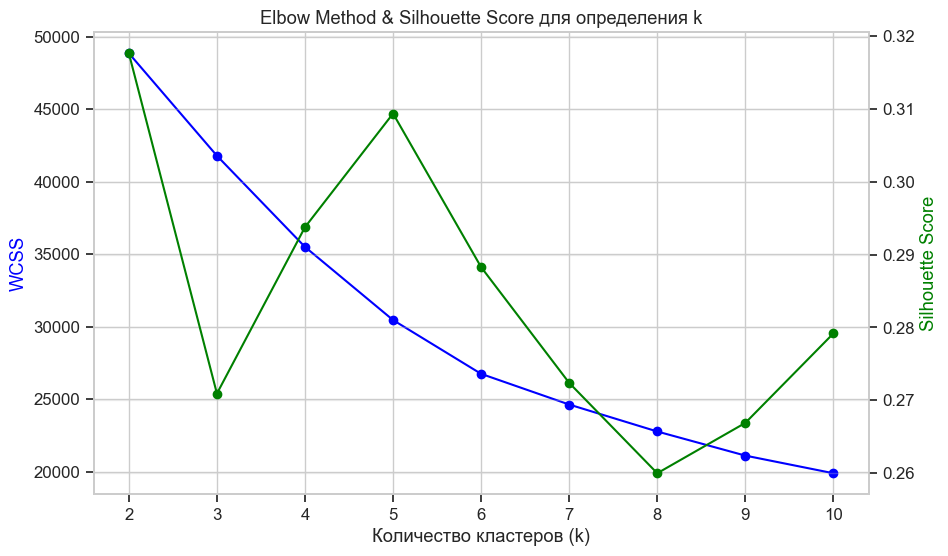

In [42]:
wcss = []
silhouette_scores = []
range_k = range(2, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('WCSS (Inertia)', color='blue')
ax1.plot(range_k, wcss, marker='o', color='blue', label='WCSS')
ax1.set_ylabel('WCSS', color='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='green')
ax2.plot(range_k, silhouette_scores, marker='o', color='green', label='Silhouette')

plt.title('Elbow Method & Silhouette Score для определения k')
plt.grid(True, alpha=0.3)
plt.savefig('../artifacts/figures/elbow_silhouette_kmeans.png')
plt.show()

In [43]:
print("Hyperparameter Tuning for K-Means")

param_grid = {
    'n_clusters': [3, 4, 5, 6, 7],
    'init': ['k-means++', 'random'],
    'n_init': [5, 7, 10, 12]
}

best_score = -1
best_params = None
best_model = None
results_log = []

for params in ParameterGrid(param_grid):
    km = KMeans(**params, random_state=42)
    labels = km.fit_predict(data_scaled)
    
    sil = silhouette_score(data_scaled, labels)
    db = davies_bouldin_score(data_scaled, labels)
    ch = calinski_harabasz_score(data_scaled, labels)
    
    current_result = {
        'params': params,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    }
    results_log.append(current_result)
    
    if sil > best_score:
        best_score = sil
        best_params = params
        best_model = km

print(f"Best K-Means Params: {best_params}")
print(f"Best Silhouette Score: {best_score:.4f}")

best_clusters = best_model.predict(data_scaled)

tuned_kmeans_results = {
    'model': 'KMeans_Tuned',
    'silhouette': best_score,
    'davies_bouldin': davies_bouldin_score(data_scaled, best_clusters),
    'calinski_harabasz': calinski_harabasz_score(data_scaled, best_clusters),
    'params': best_params
}

tuned_kmeans_results

Hyperparameter Tuning for K-Means
Best K-Means Params: {'init': 'k-means++', 'n_clusters': 5, 'n_init': 10}
Best Silhouette Score: 0.3093


{'model': 'KMeans_Tuned',
 'silhouette': 0.3093353780705341,
 'davies_bouldin': 1.2136103150059232,
 'calinski_harabasz': 3020.541924611946,
 'params': {'init': 'k-means++', 'n_clusters': 5, 'n_init': 10}}

DBSCAN

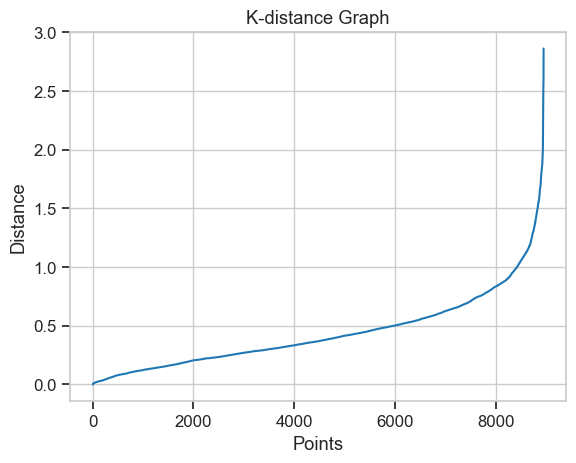

array([0.        , 0.        , 0.        , ..., 2.57797398, 2.59550698,
       2.86309137], shape=(8950,))

In [44]:
# Метод k-distance graph для подбора eps
def find_optimal_eps(data, k=5):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)
    distances = np.sort(distances[:, k-1])

    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel('Distance')
    plt.title('K-distance Graph')
    plt.savefig('../artifacts/figures/k_distance_graph_dbscan.png')
    plt.show()

    return distances

find_optimal_eps(df_scaled, k=5)

In [45]:
print("Hyperparameter Tuning for DBSCAN")

best_db_score = -1
best_db_params = None
best_db_model = None

eps_values = [0.8, 0.9, 1.0, 1.1]
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(data_scaled)

        if -1 in labels:
            mask = labels != -1
            data = data_scaled[mask]
            labels = labels[mask]
        sil = silhouette_score(data, labels)
        if sil > best_db_score:
                best_db_score = sil
                best_db_params = {'eps': eps, 'min_samples': min_s}
                best_db_model = db

if best_db_model is None:
    best_db_model = DBSCAN(eps=0.9, min_samples=10)
    best_db_params = {'eps': 0.9, 'min_samples': 10}

labels_dbscan = best_db_model.fit_predict(data_scaled)

if -1 in labels_dbscan:
    mask = labels_dbscan != -1
    data = data_scaled[mask]
    labels = labels_dbscan[mask]

sil_score = silhouette_score(data, labels)
db_score = davies_bouldin_score(data, labels)
ch_score = calinski_harabasz_score(data, labels)

dbscan_results = {
    'model': 'DBSCAN',
    'silhouette': sil_score,
    'davies_bouldin': db_score,
    'calinski_harabasz': ch_score,
    'params': best_db_params
}

dbscan_results

Hyperparameter Tuning for DBSCAN


{'model': 'DBSCAN',
 'silhouette': 0.26872254388322736,
 'davies_bouldin': 0.7984672914310943,
 'calinski_harabasz': 34.99208947896335,
 'params': {'eps': 1.0, 'min_samples': 15}}

In [46]:
print("Agglomerative Clustering")

agglo = AgglomerativeClustering(n_clusters=best_params['n_clusters'], linkage='ward')
agglo_clusters = agglo.fit_predict(data_scaled)

sil_agglo = silhouette_score(data_scaled, agglo_clusters)
db_agglo = davies_bouldin_score(data_scaled, agglo_clusters)
ch_agglo = calinski_harabasz_score(data_scaled, agglo_clusters)

agglo_results = {
    'model': 'Agglomerative_Ward',
    'silhouette': sil_agglo,
    'davies_bouldin': db_agglo,
    'calinski_harabasz': ch_agglo,
    'params': {'n_clusters': best_params['n_clusters'], 'linkage': 'ward'}
}

agglo_results

Agglomerative Clustering


{'model': 'Agglomerative_Ward',
 'silhouette': 0.2762958269072885,
 'davies_bouldin': 1.3045072526715829,
 'calinski_harabasz': 2648.790765145038,
 'params': {'n_clusters': 5, 'linkage': 'ward'}}

Эксперименты и трекинг

In [47]:
print("Logging Experiments to MLflow")

mlflow.set_experiment("Credit_Card_Clustering_Experiments")

models_to_compare = [
    baseline_results,
    tuned_kmeans_results,
    dbscan_results,
    agglo_results
]

with mlflow.start_run(run_name="Clustering_Comparison"):
    for res in models_to_compare:
        with mlflow.start_run(run_name=res['model'], nested=True):

            mlflow.log_params(res['params'])
            
            mlflow.log_metric("silhouette_score", res['silhouette'])
            mlflow.log_metric("davies_bouldin_score", res['davies_bouldin'])
            mlflow.log_metric("calinski_harabasz_score", res['calinski_harabasz'])
            
            print(f"Logged: {res['model']} | Sil: {res['silhouette']:.4f}")


    summary_df = pd.DataFrame(models_to_compare)

    csv_path = "../artifacts/experiment_summary.csv"
    summary_df.to_csv(csv_path, index=False)
    mlflow.log_artifact(csv_path)

print("Experiments logged to MLflow")

Logging Experiments to MLflow
Logged: Baseline_KMeans | Sil: 0.2938
Logged: KMeans_Tuned | Sil: 0.3093
Logged: DBSCAN | Sil: 0.2687
Logged: Agglomerative_Ward | Sil: 0.2763
Experiments logged to MLflow


Выбор финальной модели

In [48]:
summary_df.sort_values(['silhouette'], ascending=False)

,model,silhouette,davies_bouldin,calinski_harabasz,params
1,KMeans_Tuned,0.309335,1.213610,3020.541925,"{'init': 'k-means++', 'n_clusters': 5, 'n_init..."
0,Baseline_KMeans,0.293751,1.364718,3031.968228,{'n_clusters': 4}
3,Agglomerative_Ward,0.276296,1.304507,2648.790765,"{'n_clusters': 5, 'linkage': 'ward'}"
2,DBSCAN,0.268723,0.798467,34.992089,"{'eps': 1.0, 'min_samples': 15}"


`Silhouette`: чем ближе к 1, тем лучше разделение кластеров. Отрицательные значения означают, что точки отнесены не к тому кластеру.

`Davies-Bouldin`: чем ближе к 0, тем лучше (меньше перекрытия кластеров).

`Calinski-Harabasz`: чем выше, тем плотнее кластеры и дальше друг от друга.

In [49]:
df_labels = pd.DataFrame({
    'KMeans_Base': clusters_base,
    'KMeans_Tuned': best_clusters,
    'DBSCAN': labels_dbscan,
    'Agglomerative': agglo_clusters
})

print("Метки всех моделей собраны.")
df_labels.head()

Метки всех моделей собраны.


,KMeans_Base,KMeans_Tuned,DBSCAN,Agglomerative
0,3,3,0,0
1,1,1,0,2
2,3,3,0,0
3,1,1,0,2
4,3,3,0,0


In [ ]:
print("Запуск t-SNE...")
start_time = time.time()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df_selected)

print(f"t-SNE выполнено за {time.time() - start_time:.2f} секунд")
print(f"Размерность после t-SNE: {X_tsne.shape}")

fig, axes = plt.subplots(1, 4, figsize=(25, 5))

models_names = ['KMeans_Base', 'KMeans_Tuned', 'DBSCAN', 'Agglomerative']
titles = [
    'K-Means Baseline (k=4)', 
    'K-Means Tuned', 
    'DBSCAN', 
    'Agglomerative'
]

for i, (col_name, title) in enumerate(zip(models_names, titles)):
    labels = df_labels[col_name].values
    
    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=labels, 
                              cmap='viridis', 
                              alpha=0.6, 
                              s=10)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')
    axes[i].grid(True, alpha=0.3)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('../artifacts/figures/clustering_tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Запуск t-SNE...


K-Means Tuned показал лучшие результаты по метрикам silhouette (0.3093) и calinsli-harabasz (3020.54), втрое значение по davies-bouldin (1.2136) (лушчее значение по davies-bouldin дал DBSCAN - 0.798, но у него худшие результаты по остальным метрикам).

В задаче сегментации клиентов банковские данные часто имеют форму "сгустков", которые алгоритм K-Means умеет находить очень хорошо. DBSCAN же лучше работает с данными сложной формы и наличием шумов. 

Для банковской сегментации критически важно, чтобы кластеры были интерпретируемы. K-Means дает четкие центры кластеров, которые легко описать средними значениями признаков.

Основываясь на двух из трех метрик (Silhouette и Calinski-Harabasz), а также учитывая специфику задачи сегментации клиентов, лучшим методом является K-Means Tuned.

In [ ]:
print("Model Selection")


valid_models = [m for m in models_to_compare if m['silhouette'] > 0]
if valid_models:
    best_overall = max(valid_models, key=lambda x: x['silhouette'])
else:
    best_overall = tuned_kmeans_results

print(f"Best Model Selected: {best_overall['model']}")

Model Selection
Best Model Selected: KMeans_Tuned


Упаковка модели и артефактов

In [ ]:
print("Packaging Model and Artifacts")

joblib.dump(best_model, "../artifacts/best_model.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")

feature_list = selected_features

config = {
    "model_type": best_overall['model'],
    "parameters": best_overall['params'],
    "metrics": {
        "silhouette": best_overall['silhouette'],
        "davies_bouldin": best_overall['davies_bouldin'],
        "calinski_harabasz": best_overall['calinski_harabasz']
    },
    "features": feature_list
}

with open("../artifacts/best_model_config.yaml", 'w') as f:
    yaml.dump(config, f)

print("Model and artifacts saved to 'artifacts/' folder.")

Packaging Model and Artifacts
Model and artifacts saved to 'artifacts/' folder.


In [ ]:
df_clusters = pd.DataFrame(scaler.inverse_transform(df_scaled), columns=selected_features)

log_cols = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'CREDIT_LIMIT',
    'PURCHASES_TRX'
]

for col in log_cols:
    if col in df_clusters.columns:
        df_clusters[col] = np.exp(df_clusters[col]) - 1

df_clusters['KMeans_Cluster'] = best_clusters

cluster_centers = df_clusters.groupby('KMeans_Cluster').mean()
print("Характеристики кластеров (K-Means):")
print(cluster_centers.round(2))

Характеристики кластеров (K-Means):
                PURCHASES  CASH_ADVANCE  INSTALLMENTS_PURCHASES  \
KMeans_Cluster                                                    
0                  422.58       1307.35                  139.20   
1                   49.25       1928.63                    0.52   
2                 2038.92         26.63                  898.21   
3                 1158.95          4.78                  473.47   
4                 1579.58       2399.93                  643.80   

                PURCHASES_FREQUENCY  CASH_ADVANCE_FREQUENCY  PRC_FULL_PAYMENT  \
KMeans_Cluster                                                                  
0                              0.40                    0.22              0.13   
1                              0.03                    0.27              0.04   
2                              0.82                    0.00              0.79   
3                              0.61                    0.00              0.05   
4       

Финансовые:
- `PURCHASES` - Общая сумма покупок
- `CASH_ADVANCE` - Сумма снятых наличных (риск)
- `INSTALLMENTS_PURCHASES` - Сумма покупок в рассрочку (хорошие клиенты для кредитования)

Частотные:
- `PURCHASES_FREQUENCY` - Частота совершения покупок
- `CASH_ADVANCE_FREQUENCY` - Частота снятия наличных

Платежеспособность и вовлеченность:
- `PRC_FULL_PAYMENT` - Процент месяцев, в которых клиент погасил задолженность полностью (а не минимальным платежом)

Отношения клиента и банка:
- `CREDIT_LIMIT` - Кредитный лимит, отражает доверие банка клиенту
- `TENURE` - Срок обслуживания, лояльность к клиенту

- **Кластер 1** - **"Новые клиенты"** - низкое количество покупок, но довольно много снимают наличных, довольно редко берут в рассрочку. Чаще вносят только минимальный платеж, самый низкий кредитный лимит и срок обслуживания.

Новые клиенты с низким кредитным лимитом, которые чаще снимают наличные, чем совершают покупки, и редко погашают долг полностью.

- **Кластер 2** - **"Наличные"** - почти не покупают, но очень много снимают наличных, очень часто вносят только минимальный платеж, но высокие кредитные лимиты и сроки обслуживания.

Клиенты, использующие кредитную карту преимущественно как источник быстрых наличных.

- **Кластер 3** - **"Ответственные клиенты"** - много и часто покупают, активно пользуются рассрочкой, почти никогда не выводят деньги с карты, очень часто гасят долг полностью, высокий кредитный лимит и доверие банка.

Идеальные клиенты — активные, дисциплинированные, с высоким доходом. Используют карту для покупок и рассрочки, погашают долг вовремя.

- **Кластер 4** - **"Любители рассрочки"** - умеренные покупки и мало снятия наличных, активно покупают в рассрочку, но почим всегда вносят только минимальные платежи. Высокий кредитный лимит и самый долгий срок обслуживания.

Лояльные клиенты, которые предпочитают покупки в рассрочку, но не погашают долг полностью — приносят доход за счёт процентов.

- **Кластер 5** - **"Активные пользователи"** - много и часто покупают, но также много и часто снимают наличных. Пользуются рассрочкой, но почти никогда не платят полностью. Но самый высокий кредитный лимит и срок обслуживания.

Активные клиенты с высоким лимитом, которые максимально используют все возможности карты, но не охотно погашают долг. Высокий потенциал дохода, но и высокий риск.

Кластеры 2 и 3 — наиболее ценные для банка (стабильный доход при умеренном риске). Кластеры 1 и 4 требуют особого внимания к управлению кредитным риском, несмотря на высокий потенциал дохода.

In [ ]:
new_client_data = pd.DataFrame([{
    'PURCHASES': 1000.0,
    'CASH_ADVANCE': 100.0,
    'INSTALLMENTS_PURCHASES': 200.0,
    'PURCHASES_FREQUENCY': 0.9,
    'CASH_ADVANCE_FREQUENCY': 0.1,
    'PRC_FULL_PAYMENT': 0.9,
    'CREDIT_LIMIT': 5000.0,
    'TENURE': 12
}])

In [ ]:
client_features = new_client_data

LOG_COLUMNS = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'CASH_ADVANCE_TRX',
    'CREDIT_LIMIT', 'PURCHASES_TRX'
]
for col in LOG_COLUMNS:
    if col in client_features.columns:
        client_features[col] = np.log1p(client_features[col])
        
# Масштабирование
client_scaled = scaler.transform(client_features)

# Предсказание кластера
cluster_label = best_model.predict(client_scaled)[0]

cluster_label

np.int32(2)